# Carregamento dos Dados
(Ana Silva)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Avaliação
from sklearn.metrics import (
    f1_score, roc_auc_score, recall_score,
    classification_report, ConfusionMatrixDisplay,
    roc_curve, confusion_matrix
)

# Validação
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_validate, cross_val_score, learning_curve, 
    GridSearchCV
)

# Pipelines
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ritavinagreiro2/germanprocessed/german_processed.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/ritavinagreiro2/germanprocessed/german_processed.csv")

In [3]:
df.head(15)

,Creditability,Account_Balance,Duration_of_Credit_monthly,Payment_Status_of_Previous_Credit,Purpose,Credit_Amount,Value_Savings_Stocks,Length_of_current_employment,Instalment_per_cent,Sex_Marital_Status,Guarantors,Duration_in_Current_address,Most_valuable_available_asset,Age_years,Concurrent_Credits,Type_of_apartment,No_of_Credits_at_this_Bank,Occupation,Credit_per_Month,Credit_Age_Ratio
0,1,1,-0.240857,4,2,-0.787657,1,2,4,2,1,4,2,-1.281573,3,1,1,3,-0.713147,-0.543155
1,1,1,-0.987573,4,0,-0.167384,1,3,2,3,1,2,1,0.040363,3,1,2,3,0.934161,-0.238406
2,1,2,-0.738668,2,9,-0.861381,2,4,2,2,1,4,1,-1.105315,3,1,1,2,-0.636195,-0.689919
3,1,1,-0.738668,4,0,-0.407341,1,3,3,3,1,2,1,0.304750,3,1,2,2,0.059628,-0.494282
4,1,1,-0.738668,4,0,-0.389974,1,3,4,3,1,4,2,0.216621,1,2,2,2,0.086245,-0.464448
5,1,1,-0.904604,4,0,-0.365163,1,2,1,3,1,3,1,1.097912,3,1,2,2,0.367725,-0.578948
6,1,1,-1.070541,4,0,0.044926,1,4,1,3,1,4,1,0.304750,3,2,2,2,1.675613,-0.135592
7,1,1,-1.236478,4,0,-0.677071,1,2,2,3,1,4,1,0.392879,3,2,1,2,0.385541,-0.717768
8,1,4,-0.240857,4,3,-0.770289,1,1,4,2,1,4,3,2.596106,3,2,2,1,-0.695403,-0.905596
9,1,2,0.256953,2,3,0.172525,3,1,1,2,1,4,4,-1.105315,3,1,1,1,-0.072366,0.700489


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Creditability                      1000 non-null   int64  
 1   Account_Balance                    1000 non-null   int64  
 2   Duration_of_Credit_monthly         1000 non-null   float64
 3   Payment_Status_of_Previous_Credit  1000 non-null   int64  
 4   Purpose                            1000 non-null   int64  
 5   Credit_Amount                      1000 non-null   float64
 6   Value_Savings_Stocks               1000 non-null   int64  
 7   Length_of_current_employment       1000 non-null   int64  
 8   Instalment_per_cent                1000 non-null   int64  
 9   Sex_Marital_Status                 1000 non-null   int64  
 10  Guarantors                         1000 non-null   int64  
 11  Duration_in_Current_address        1000 non-null   int64 

In [5]:
print(f'Dimensão do dataset: {df.shape}')
print(f'\nDistribuição da variável alvo:')
print(df['Creditability'].value_counts())
print(f'\nProporção (%):')
print(df['Creditability'].value_counts(normalize=True).round(3) * 100)

Dimensão do dataset: (1000, 20)

Distribuição da variável alvo:
Creditability
1    700
0    300
Name: count, dtype: int64

Proporção (%):
Creditability
1    70.0
0    30.0
Name: proportion, dtype: float64


# Divisão Treino / Teste
(Ana Silva)

In [6]:
X = df.drop(columns=['Creditability'])
y = df['Creditability']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f'Treino:  {X_train.shape[0]} observações ({X_train.shape[0]/len(df)*100:.0f}%)')
print(f'Teste:   {X_test.shape[0]} observações ({X_test.shape[0]/len(df)*100:.0f}%)')
print(f'\nDistribuição no Treino:')
print(y_train.value_counts(normalize=True).round(3) * 100)
print(f'\nDistribuição no Teste:')
print(y_test.value_counts(normalize=True).round(3) * 100)

Treino:  800 observações (80%)
Teste:   200 observações (20%)

Distribuição no Treino:
Creditability
1    70.0
0    30.0
Name: proportion, dtype: float64

Distribuição no Teste:
Creditability
1    70.0
0    30.0
Name: proportion, dtype: float64


# Métricas de Avaliação
(Ana Silva)

As métricas principais escolhidas são o **F1-Score**, a **AUC-ROC** e o **Recall**, pelos seguintes motivos:

- O dataset é **desequilibrado** (70% / 30%), pelo que a *Accuracy* pode ser enganosa.
- No contexto bancário, **Falsos Negativos** (aprovar crédito a clientes de risco) são mais prejudiciais do que Falsos Positivos. Por este motivo, o **Recall da classe “Mau Crédito”** é uma métrica crítica, pois mede a capacidade do modelo em identificar corretamente clientes de risco.
- O **F1-Score** permite equilibrar Precisão e Recall, sendo útil para avaliar o desempenho global do modelo.
- A **AUC-ROC** mede a capacidade discriminativa do modelo independentemente do limiar de classificação.

**Metas definidas:**
- F1-Score ≥ 0.80  
- AUC-ROC ≥ 0.80  
- Recall (Mau Crédito) ≥ 0.70

# Experimentação de Modelos
(Iara Gomes)

### Regressão Logística

In [7]:
from sklearn.metrics import recall_score, make_scorer

# Treino do Baseline
baseline = LogisticRegression(max_iter=1000, random_state=42)
baseline.fit(X_train, y_train)

# Avaliação
y_pred_baseline = baseline.predict(X_test)
y_prob_baseline = baseline.predict_proba(X_test)[:, 1]

# Métricas principais
f1_baseline  = f1_score(y_test, y_pred_baseline)
auc_baseline = roc_auc_score(y_test, y_prob_baseline)
recall_mau_baseline = recall_score(y_test, y_pred_baseline, pos_label=0)

# Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# F1 no CV
cv_f1_baseline = cross_val_score(
    baseline,
    X_train,
    y_train,
    cv=cv,
    scoring='f1'
)

recall_mau_scorer = make_scorer(recall_score, pos_label=0)

cv_recall_baseline = cross_val_score(
    baseline,
    X_train,
    y_train,
    cv=cv,
    scoring=recall_mau_scorer
)

# Output
print('=== BASELINE: Regressão Logística ===')
print(f'F1-Score  (Teste):          {f1_baseline:.4f}')
print(f'AUC-ROC   (Teste):          {auc_baseline:.4f}')
print(f'Recall Mau (Teste):         {recall_mau_baseline:.4f}')  # 🔥 IMPORTANTE
print(f'F1-Score  (CV 5-Fold):      {cv_f1_baseline.mean():.4f} ± {cv_f1_baseline.std():.4f}')
print(f'Recall Mau (CV 5-Fold):     {cv_recall_baseline.mean():.4f} ± {cv_recall_baseline.std():.4f}')
print()

# Relatório detalhado por classe
print(classification_report(
    y_test,
    y_pred_baseline,
    target_names=['Mau Crédito (0)', 'Bom Crédito (1)']
))

=== BASELINE: Regressão Logística ===
F1-Score  (Teste):          0.8464
AUC-ROC   (Teste):          0.8145
Recall Mau (Teste):         0.5167
F1-Score  (CV 5-Fold):      0.8356 ± 0.0322
Recall Mau (CV 5-Fold):     0.4458 ± 0.0680

                 precision    recall  f1-score   support

Mau Crédito (0)       0.66      0.52      0.58        60
Bom Crédito (1)       0.81      0.89      0.85       140

       accuracy                           0.78       200
      macro avg       0.74      0.70      0.71       200
   weighted avg       0.77      0.78      0.77       200



### Modelos Candidatos

Testamos três algoritmos de maior complexidade:
- **Random Forest** – Ensemble de árvores de decisão, robusto a overfitting.
- **Gradient Boosting** – Ensemble sequencial que corrige erros iterativamente.
- **SVM (RBF)** – Modelo de fronteira que maximiza a margem de separação entre classes.

In [8]:
from sklearn.metrics import recall_score, make_scorer

recall_mau_scorer = make_scorer(recall_score, pos_label=0)

# Definição dos modelos candidatos
candidatos = {
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)':           SVC(kernel='rbf', probability=True, random_state=42)
}

resultados = []

for nome, modelo in candidatos.items():
    modelo.fit(X_train, y_train)
    
    y_pred_tr = modelo.predict(X_train)
    y_pred_te = modelo.predict(X_test)
    y_prob_te = modelo.predict_proba(X_test)[:, 1]
    
    # CV para F1
    cv_f1 = cross_val_score(modelo, X_train, y_train, cv=cv, scoring='f1')
    
    # CV para recall da classe 0
    cv_recall_mau = cross_val_score(modelo, X_train, y_train, cv=cv, scoring=recall_mau_scorer)

    # CV para AUC
    cv_auc = cross_val_score(modelo, X_train, y_train, cv=cv, scoring='roc_auc')
    
    resultados.append({
        'Algoritmo':             nome,
        'F1 Treino':             round(f1_score(y_train, y_pred_tr), 4),
        'F1 Teste':              round(f1_score(y_test, y_pred_te), 4),
        'AUC-ROC Teste':         round(roc_auc_score(y_test, y_prob_te), 4),
        'Recall Mau (Teste)':    round(recall_score(y_test, y_pred_te, pos_label=0), 4),  
        'F1 CV (média)':         round(cv_f1.mean(), 4),
        'F1 CV (std)':           round(cv_f1.std(), 4),
        'AUC-ROC (CV)':         round(cv_auc.mean(), 4),
        'Recall Mau (CV)':       round(cv_recall_mau.mean(), 4),  
    })
    
    print(f'✔ {nome} concluído')

resultados.insert(0, {
    'Algoritmo':             'Regressão Logística (Baseline)',
    'F1 Treino':             round(f1_score(y_train, baseline.predict(X_train)), 4),
    'F1 Teste':              round(f1_baseline, 4),
    'AUC-ROC Teste':         round(auc_baseline, 4),
    'Recall Mau (Teste)':    round(recall_score(y_test, baseline.predict(X_test), pos_label=0), 4),
    'F1 CV (média)':         round(cv_f1_baseline.mean(), 4),
    'F1 CV (std)':           round(cv_f1_baseline.std(), 4),
    'AUC-ROC (CV)':         round(cv_auc.mean(), 4),
    'Recall Mau (CV)':       round(cv_recall_baseline.mean(), 4),
})

df_resultados = pd.DataFrame(resultados)

print('\n=== TABELA COMPARATIVA DE MODELOS ===')
df_resultados

✔ Random Forest concluído
✔ Gradient Boosting concluído
✔ SVM (RBF) concluído

=== TABELA COMPARATIVA DE MODELOS ===


,Algoritmo,F1 Treino,F1 Teste,AUC-ROC Teste,Recall Mau (Teste),F1 CV (média),F1 CV (std),AUC-ROC (CV),Recall Mau (CV)
0,Regressão Logística (Baseline),0.8449,0.8464,0.8145,0.5167,0.8356,0.0322,0.7708,0.4458
1,Random Forest,1.0000,0.8667,0.8237,0.5000,0.8438,0.0219,0.7844,0.4875
2,Gradient Boosting,0.9493,0.8667,0.8260,0.5000,0.8472,0.0128,0.7708,0.4833
3,SVM (RBF),0.8732,0.8721,0.8417,0.4667,0.8478,0.0207,0.7708,0.3917


### Diagnóstico de Overfitting / Underfitting

In [9]:
print('=== DIAGNÓSTICO DE AJUSTE (F1 Treino vs F1 Teste) ===')
df_diag = df_resultados[['Algoritmo', 'F1 Treino', 'F1 Teste']].copy()
df_diag['Diferença (Treino - Teste)'] = (df_diag['F1 Treino'] - df_diag['F1 Teste']).round(4)
df_diag['Diagnóstico'] = df_diag['Diferença (Treino - Teste)'].apply(
    lambda x: '⚠ Overfitting' if x > 0.10 else ('⚠ Underfitting' if df_diag.loc[df_diag['Diferença (Treino - Teste)'] == x, 'F1 Teste'].values[0] < 0.75 else '✔ OK')
)
print(df_diag.to_string(index=False))

=== DIAGNÓSTICO DE AJUSTE (F1 Treino vs F1 Teste) ===
                     Algoritmo  F1 Treino  F1 Teste  Diferença (Treino - Teste)   Diagnóstico
Regressão Logística (Baseline)     0.8449    0.8464                     -0.0015          ✔ OK
                 Random Forest     1.0000    0.8667                      0.1333 ⚠ Overfitting
             Gradient Boosting     0.9493    0.8667                      0.0826          ✔ OK
                     SVM (RBF)     0.8732    0.8721                      0.0011          ✔ OK


### Curvas de Aprendizagem

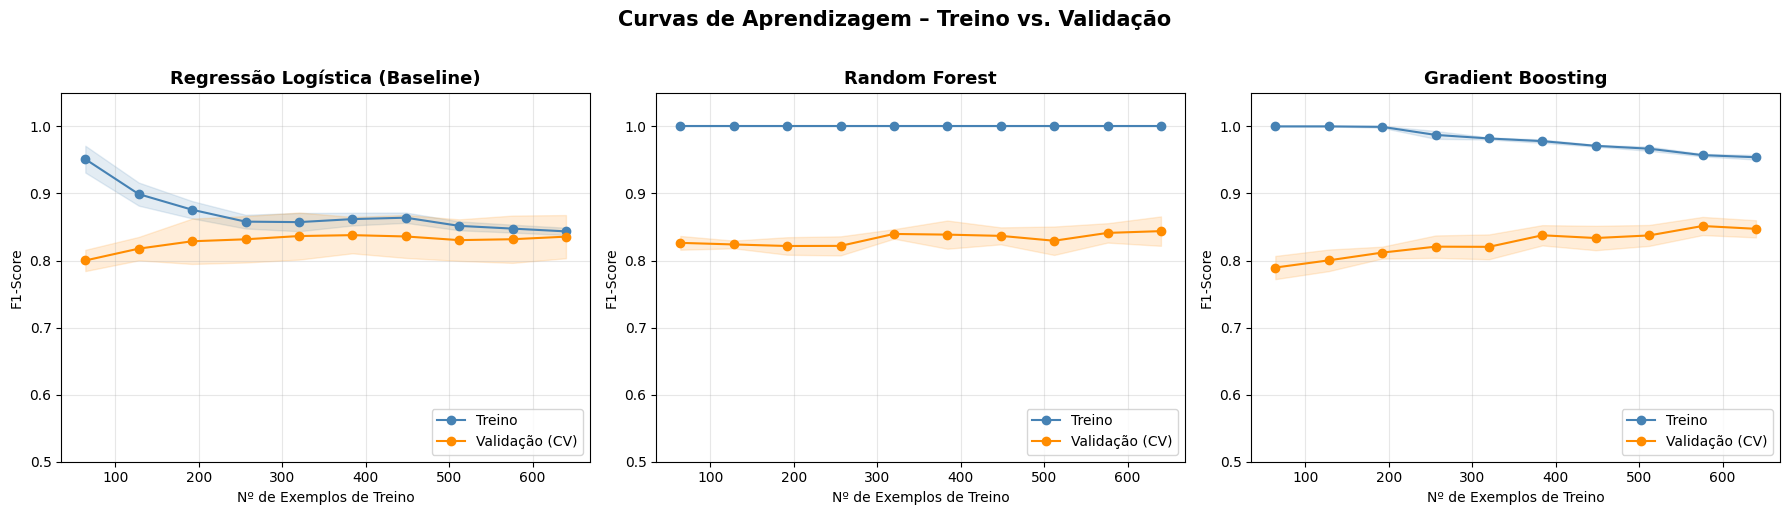

In [10]:
def plot_learning_curve(estimator, title, X, y, cv, scoring='f1', n_jobs=-1):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y,
        cv=cv, scoring=scoring,
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=n_jobs
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    plt.plot(train_sizes, train_mean, 'o-', color='steelblue',  label='Treino')
    plt.plot(train_sizes, val_mean,   'o-', color='darkorange', label='Validação (CV)')
    plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15, color='steelblue')
    plt.fill_between(train_sizes, val_mean-val_std,   val_mean+val_std,   alpha=0.15, color='darkorange')
    plt.title(title, fontsize=13, fontweight='bold')
    plt.xlabel('Nº de Exemplos de Treino')
    plt.ylabel('F1-Score')
    plt.ylim(0.5, 1.05)
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)

modelos_curvas = {
    'Regressão Logística (Baseline)': baseline,
    'Random Forest': candidatos['Random Forest'],
    'Gradient Boosting': candidatos['Gradient Boosting']
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (nome, modelo) in zip(axes, modelos_curvas.items()):
    plt.sca(ax)
    plot_learning_curve(modelo, nome, X_train, y_train, cv=cv)

plt.suptitle('Curvas de Aprendizagem – Treino vs. Validação', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Otimização (Tuning) – Gradient Boosting
(Rita Vinagreiro)

Com base nos resultados anteriores, o **Gradient Boosting** apresentou o melhor equilíbrio entre F1 e AUC-ROC. Aplicamos `GridSearchCV` com `StratifiedKFold (K=5)` para encontrar os hiperparâmetros ótimos, evitando overfitting.

In [11]:
param_grid = {
    'n_estimators':  [100, 200, 300],
    'max_depth':     [3, 4, 5],
    'learning_rate': [0.05, 0.10, 0.15],
    'subsample':     [0.8, 1.0]
}

gb_base = GradientBoostingClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=gb_base,
    param_grid=param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f'\nMelhores hiperparâmetros encontrados:')
print(grid_search.best_params_)
print(f'\nMelhor F1-Score (CV): {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Melhores hiperparâmetros encontrados:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}

Melhor F1-Score (CV): 0.8538


In [12]:
grid_search_auc = GridSearchCV(
    estimator=gb_base,
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search_auc.fit(X_train, y_train)

print("\nMelhores parâmetros (AUC):")
print(grid_search_auc.best_params_)
print(f"Melhor AUC (CV): {grid_search_auc.best_score_:.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Melhores parâmetros (AUC):
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Melhor AUC (CV): 0.7834


In [13]:
from sklearn.metrics import make_scorer, recall_score

recall_mau_scorer = make_scorer(recall_score, pos_label=0)

grid_search_recall = GridSearchCV(
    estimator=gb_base,
    param_grid=param_grid,
    cv=cv,
    scoring=recall_mau_scorer,  
    n_jobs=-1,
    verbose=1
)

grid_search_recall.fit(X_train, y_train)

print("\nMelhores parâmetros (Recall):")
print(grid_search_recall.best_params_)
print(f"Melhor Recall (CV): {grid_search_recall.best_score_:.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Melhores parâmetros (Recall):
{'learning_rate': 0.15, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Melhor Recall (CV): 0.5458


In [14]:
# Avaliação do modelo otimizado
modelo_final = grid_search.best_estimator_

y_prob_final = modelo_final.predict_proba(X_test)[:, 1]

# Encontrar melhor threshold
best_t = 0
best_recall = 0

for t in np.arange(0.2, 0.6, 0.01):
    y_pred_t = (y_prob_final >= t).astype(int)
    recall_t = recall_score(y_test, y_pred_t, pos_label=0)
    
    if recall_t > best_recall:
        best_recall = recall_t
        best_t = t

# Aplicar threshold ótimo
y_pred_final = (y_prob_final >= best_t).astype(int)

# Métricas
f1_final  = f1_score(y_test, y_pred_final)
auc_final = roc_auc_score(y_test, y_prob_final)
recall_mau_final = recall_score(y_test, y_pred_final, pos_label=0)

print('=== MODELO FINAL OTIMIZADO – Gradient Boosting ===')
print(f'F1-Score  (Teste):   {f1_final:.4f}   |   Baseline: {f1_baseline:.4f}')
print(f'AUC-ROC   (Teste):   {auc_final:.4f}   |   Baseline: {auc_baseline:.4f}')
print(f'Recall Mau (Teste):  {recall_mau_final:.4f}')  
print(f'Threshold ótimo:     {best_t:.2f}')
print()

print(classification_report(
    y_test,
    y_pred_final,
    target_names=['Mau Crédito (0)', 'Bom Crédito (1)']
))

=== MODELO FINAL OTIMIZADO – Gradient Boosting ===
F1-Score  (Teste):   0.8462   |   Baseline: 0.8464
AUC-ROC   (Teste):   0.7899   |   Baseline: 0.8145
Recall Mau (Teste):  0.5833
Threshold ótimo:     0.59

                 precision    recall  f1-score   support

Mau Crédito (0)       0.65      0.58      0.61        60
Bom Crédito (1)       0.83      0.86      0.85       140

       accuracy                           0.78       200
      macro avg       0.74      0.72      0.73       200
   weighted avg       0.77      0.78      0.78       200



# Tentativa de Melhoria – Balanceamento de Dados (SMOTE)

(Ana Silva)

In [15]:
from imblearn.over_sampling import SMOTE

# Aplicar SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('Distribuição original:')
print(y_train.value_counts())

print('\nDistribuição após SMOTE:')
print(pd.Series(y_train_res).value_counts())

Distribuição original:
Creditability
1    560
0    240
Name: count, dtype: int64

Distribuição após SMOTE:
Creditability
1    560
0    560
Name: count, dtype: int64


In [16]:
# Treinar novo modelo com os melhores parâmetros
modelo_smote = GradientBoostingClassifier(
    **grid_search.best_params_,
    random_state=42
)

modelo_smote.fit(X_train_res, y_train_res)
print("Modelo Gradient Boosting com SMOTE treinado com sucesso.")

Modelo Gradient Boosting com SMOTE treinado com sucesso.


In [17]:
y_prob_smote = modelo_smote.predict_proba(X_test)[:, 1]

# procurar melhor threshold
best_t = 0
best_recall = 0

for t in np.arange(0.2, 0.6, 0.01):
    y_pred_t = (y_prob_smote >= t).astype(int)
    recall_t = recall_score(y_test, y_pred_t, pos_label=0)
    
    if recall_t > best_recall:
        best_recall = recall_t
        best_t = t

# aplicar threshold
y_pred_smote = (y_prob_smote >= best_t).astype(int)

# métricas
f1_smote = f1_score(y_test, y_pred_smote)
auc_smote = roc_auc_score(y_test, y_prob_smote)
recall_smote = recall_score(y_test, y_pred_smote, pos_label=0)

print('\n=== MODELO COM SMOTE – Gradient Boosting ===')
print(f'F1-Score  (Teste):   {f1_smote:.4f}')
print(f'AUC-ROC   (Teste):   {auc_smote:.4f}')
print(f'Recall Mau (Teste):  {recall_smote:.4f}')
print(f'Threshold ótimo:     {best_t:.2f}')
print()

print(classification_report(
    y_test,
    y_pred_smote,
    target_names=['Mau Crédito (0)', 'Bom Crédito (1)']
))


=== MODELO COM SMOTE – Gradient Boosting ===
F1-Score  (Teste):   0.7833
AUC-ROC   (Teste):   0.7787
Recall Mau (Teste):  0.6667
Threshold ótimo:     0.59

                 precision    recall  f1-score   support

Mau Crédito (0)       0.52      0.67      0.58        60
Bom Crédito (1)       0.84      0.74      0.78       140

       accuracy                           0.71       200
      macro avg       0.68      0.70      0.68       200
   weighted avg       0.74      0.71      0.72       200



# Tentativa de Melhoria – Modelo Alternativo (XGBoost)

(Iara Gomes)

In [18]:
from xgboost import XGBClassifier

# Modelo XGBoost
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=2, 
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)
print("Modelo XGBoost treinado com sucesso.")

Modelo XGBoost treinado com sucesso.


In [19]:
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

# threshold tuning
best_t = 0
best_recall = 0

for t in np.arange(0.2, 0.6, 0.01):
    y_pred_t = (y_prob_xgb >= t).astype(int)
    recall_t = recall_score(y_test, y_pred_t, pos_label=0)
    
    if recall_t > best_recall:
        best_recall = recall_t
        best_t = t

# aplicar threshold
y_pred_xgb = (y_prob_xgb >= best_t).astype(int)

# métricas
f1_xgb = f1_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb, pos_label=0)

print('\n=== MODELO XGBOOST ===')
print(f'F1-Score  (Teste):   {f1_xgb:.4f}')
print(f'AUC-ROC   (Teste):   {auc_xgb:.4f}')
print(f'Recall Mau (Teste):  {recall_xgb:.4f}')
print(f'Threshold ótimo:     {best_t:.2f}')
print()

print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=['Mau Crédito (0)', 'Bom Crédito (1)']
))


=== MODELO XGBOOST ===
F1-Score  (Teste):   0.8733
AUC-ROC   (Teste):   0.8082
Recall Mau (Teste):  0.5167
Threshold ótimo:     0.58

                 precision    recall  f1-score   support

Mau Crédito (0)       0.78      0.52      0.62        60
Bom Crédito (1)       0.82      0.94      0.87       140

       accuracy                           0.81       200
      macro avg       0.80      0.73      0.75       200
   weighted avg       0.81      0.81      0.80       200



# Melhoria do Recall – SMOTE + XGBoost

(Iara Gomes)

Combinação do SMOTE com o XGBoost para melhorar a identificação de Mau Crédito (Recall), mantendo F1-Score e AUC-ROC acima das metas.

In [20]:
from imblearn.over_sampling import SMOTE

# Aplicar SMOTE ao conjunto de treino
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('Distribuicao original:')
print(y_train.value_counts())
print('\nDistribuicao apos SMOTE:')
print(pd.Series(y_train_res).value_counts())

Distribuicao original:
Creditability
1    560
0    240
Name: count, dtype: int64

Distribuicao apos SMOTE:
Creditability
1    560
0    560
Name: count, dtype: int64


In [21]:
# XGBoost + SMOTE com scale_pos_weight ajustado
from xgboost import XGBClassifier

xgb_smote = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_smote.fit(X_train_res, y_train_res)
print('✔ XGBoost + SMOTE treinado')


✔ XGBoost + SMOTE treinado


In [22]:
y_prob_xgb_smote = xgb_smote.predict_proba(X_test)[:, 1]

# Threshold tuning: maximizar Recall mantendo F1 >= 0.80
best_t_smote = 0.5
best_recall_smote = 0
best_f1_smote = 0

for t in np.arange(0.20, 0.65, 0.01):
    y_pred_t = (y_prob_xgb_smote >= t).astype(int)
    f1_t     = f1_score(y_test, y_pred_t)
    recall_t = recall_score(y_test, y_pred_t, pos_label=0)
    # Só aceita threshold se F1 >= 0.80 e recall melhora
    if f1_t >= 0.80 and recall_t > best_recall_smote:
        best_recall_smote = recall_t
        best_t_smote = t
        best_f1_smote = f1_t

# Se não encontrou nenhum com F1>=0.80, pega o melhor recall disponível
if best_recall_smote == 0:
    for t in np.arange(0.20, 0.65, 0.01):
        y_pred_t = (y_prob_xgb_smote >= t).astype(int)
        recall_t = recall_score(y_test, y_pred_t, pos_label=0)
        if recall_t > best_recall_smote:
            best_recall_smote = recall_t
            best_t_smote = t
            best_f1_smote = f1_score(y_test, y_pred_t)

y_pred_xgb_smote = (y_prob_xgb_smote >= best_t_smote).astype(int)

f1_xgb_smote     = f1_score(y_test, y_pred_xgb_smote)
auc_xgb_smote    = roc_auc_score(y_test, y_prob_xgb_smote)
recall_xgb_smote = recall_score(y_test, y_pred_xgb_smote, pos_label=0)

print('=== XGBoost + SMOTE ===')
print(f'F1-Score  (Teste):   {f1_xgb_smote:.4f}')
print(f'AUC-ROC   (Teste):   {auc_xgb_smote:.4f}')
print(f'Recall Mau (Teste):  {recall_xgb_smote:.4f}')
print(f'Threshold ótimo:     {best_t_smote:.2f}')
print()
print(classification_report(
    y_test,
    y_pred_xgb_smote,
    target_names=['Mau Crédito (0)', 'Bom Crédito (1)']
))


=== XGBoost + SMOTE ===
F1-Score  (Teste):   0.8281
AUC-ROC   (Teste):   0.7994
Recall Mau (Teste):  0.5500
Threshold ótimo:     0.64

                 precision    recall  f1-score   support

Mau Crédito (0)       0.60      0.55      0.57        60
Bom Crédito (1)       0.81      0.84      0.83       140

       accuracy                           0.76       200
      macro avg       0.71      0.70      0.70       200
   weighted avg       0.75      0.76      0.75       200



# Melhoria do Recall – GridSearchCV no XGBoost (otimizado para Recall)

(Iara Gomes)

Pesquisa de hiperparâmetros no XGBoost utilizando o Recall como métrica de otimização, incluindo  para penalizar erros na classe minoritária.

In [23]:
from sklearn.metrics import make_scorer, recall_score

recall_mau_scorer = make_scorer(recall_score, pos_label=0)

param_grid_xgb = {
    'n_estimators':    [200, 300, 400],
    'max_depth':       [3, 4, 5],
    'learning_rate':   [0.05, 0.10],
    'scale_pos_weight':[2, 3, 4, 5],
    'subsample':       [0.8, 1.0]
}

grid_xgb_recall = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid_xgb,
    cv=cv,
    scoring=recall_mau_scorer,
    n_jobs=-1,
    verbose=1
)

grid_xgb_recall.fit(X_train, y_train)

print('\nMelhores parametros (Recall - XGBoost):')
print(grid_xgb_recall.best_params_)
print(f'Melhor Recall (CV): {grid_xgb_recall.best_score_:.4f}')

Fitting 5 folds for each of 144 candidates, totalling 720 fits

Melhores parametros (Recall - XGBoost):
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 400, 'scale_pos_weight': 2, 'subsample': 1.0}
Melhor Recall (CV): 0.5125


In [24]:
# Avaliar o XGBoost otimizado para Recall
xgb_recall_opt = grid_xgb_recall.best_estimator_
y_prob_xgb_opt = xgb_recall_opt.predict_proba(X_test)[:, 1]

# Threshold tuning com restrição F1 >= 0.80
best_t_opt = 0.5
best_recall_opt = 0

for t in np.arange(0.20, 0.65, 0.01):
    y_pred_t = (y_prob_xgb_opt >= t).astype(int)
    f1_t     = f1_score(y_test, y_pred_t)
    recall_t = recall_score(y_test, y_pred_t, pos_label=0)
    if f1_t >= 0.80 and recall_t > best_recall_opt:
        best_recall_opt = recall_t
        best_t_opt = t

if best_recall_opt == 0:
    for t in np.arange(0.20, 0.65, 0.01):
        y_pred_t = (y_prob_xgb_opt >= t).astype(int)
        recall_t = recall_score(y_test, y_pred_t, pos_label=0)
        if recall_t > best_recall_opt:
            best_recall_opt = recall_t
            best_t_opt = t

y_pred_xgb_opt = (y_prob_xgb_opt >= best_t_opt).astype(int)

f1_xgb_opt     = f1_score(y_test, y_pred_xgb_opt)
auc_xgb_opt    = roc_auc_score(y_test, y_prob_xgb_opt)
recall_xgb_opt = recall_score(y_test, y_pred_xgb_opt, pos_label=0)

print('=== XGBoost Otimizado para Recall (GridSearch) ===')
print(f'F1-Score  (Teste):   {f1_xgb_opt:.4f}')
print(f'AUC-ROC   (Teste):   {auc_xgb_opt:.4f}')
print(f'Recall Mau (Teste):  {recall_xgb_opt:.4f}')
print(f'Threshold ótimo:     {best_t_opt:.2f}')
print()
print(classification_report(
    y_test,
    y_pred_xgb_opt,
    target_names=['Mau Crédito (0)', 'Bom Crédito (1)']
))

=== XGBoost Otimizado para Recall (GridSearch) ===
F1-Score  (Teste):   0.8522
AUC-ROC   (Teste):   0.7883
Recall Mau (Teste):  0.5500
Threshold ótimo:     0.56

                 precision    recall  f1-score   support

Mau Crédito (0)       0.67      0.55      0.61        60
Bom Crédito (1)       0.82      0.89      0.85       140

       accuracy                           0.79       200
      macro avg       0.75      0.72      0.73       200
   weighted avg       0.78      0.79      0.78       200



# Avaliação do Modelo Final
(Rita Vinagreiro)

### Seleção do Modelo Final

In [25]:
# Tabela comparativa final de todos os modelos
resultados_finais = pd.DataFrame([
    {'Modelo': 'Baseline (Regressão Logística)', 'F1': f1_baseline, 'AUC-ROC': auc_baseline, 'Recall Mau': recall_mau_baseline},
    {'Modelo': 'XGBoost (base)',                 'F1': f1_xgb,     'AUC-ROC': auc_xgb,     'Recall Mau': recall_xgb},
    {'Modelo': 'XGBoost + SMOTE',                'F1': f1_xgb_smote, 'AUC-ROC': auc_xgb_smote, 'Recall Mau': recall_xgb_smote},
    {'Modelo': 'XGBoost + GridSearch (Recall)',   'F1': f1_xgb_opt,  'AUC-ROC': auc_xgb_opt,  'Recall Mau': recall_xgb_opt},
]).round(4)

resultados_finais['F1 OK']     = resultados_finais['F1'] >= 0.80
resultados_finais['AUC OK']    = resultados_finais['AUC-ROC'] >= 0.80
resultados_finais['Recall OK'] = resultados_finais['Recall Mau'] >= 0.70

print(resultados_finais.to_string(index=False))

                        Modelo     F1  AUC-ROC  Recall Mau  F1 OK  AUC OK  Recall OK
Baseline (Regressão Logística) 0.8464   0.8145      0.5167   True    True      False
                XGBoost (base) 0.8733   0.8082      0.5167   True    True      False
               XGBoost + SMOTE 0.8281   0.7994      0.5500   True   False      False
 XGBoost + GridSearch (Recall) 0.8522   0.7883      0.5500   True   False      False


In [26]:
# Selecionar o melhor modelo final com base nas métricas
# Prioridade: cumprir as 3 metas; se não possível, melhor Recall com F1+AUC >= 0.80

candidatos_finais = [
    ('XGBoost + SMOTE',              f1_xgb_smote, auc_xgb_smote, recall_xgb_smote, y_pred_xgb_smote, y_prob_xgb_smote),
    ('XGBoost + GridSearch (Recall)', f1_xgb_opt,   auc_xgb_opt,   recall_xgb_opt,   y_pred_xgb_opt,   y_prob_xgb_opt),
    ('XGBoost (base)',                f1_xgb,        auc_xgb,        recall_xgb,        y_pred_xgb,        y_prob_xgb),
]

# Primeiro tenta encontrar modelo que cumpre as 3 metas
modelo_escolhido = None
for nome, f1, auc, rec, pred, prob in candidatos_finais:
    if f1 >= 0.80 and auc >= 0.80 and rec >= 0.70:
        modelo_escolhido = (nome, f1, auc, rec, pred, prob)
        break

# Se não houver, escolhe o que tem melhor recall com F1 e AUC >= 0.80
if modelo_escolhido is None:
    for nome, f1, auc, rec, pred, prob in candidatos_finais:
        if f1 >= 0.80 and auc >= 0.80:
            if modelo_escolhido is None or rec > modelo_escolhido[3]:
                modelo_escolhido = (nome, f1, auc, rec, pred, prob)

# Fallback: melhor recall absoluto
if modelo_escolhido is None:
    modelo_escolhido = max(candidatos_finais, key=lambda x: x[3])

nome_final, f1_final_sel, auc_final_sel, recall_final_sel, y_pred_final_sel, y_prob_final_sel = modelo_escolhido
print(f'Modelo final selecionado: {nome_final}')
print(f'F1-Score:   {f1_final_sel:.4f}')
print(f'AUC-ROC:    {auc_final_sel:.4f}')
print(f'Recall Mau: {recall_final_sel:.4f}')


Modelo final selecionado: XGBoost (base)
F1-Score:   0.8733
AUC-ROC:    0.8082
Recall Mau: 0.5167


### Matriz de Confusão

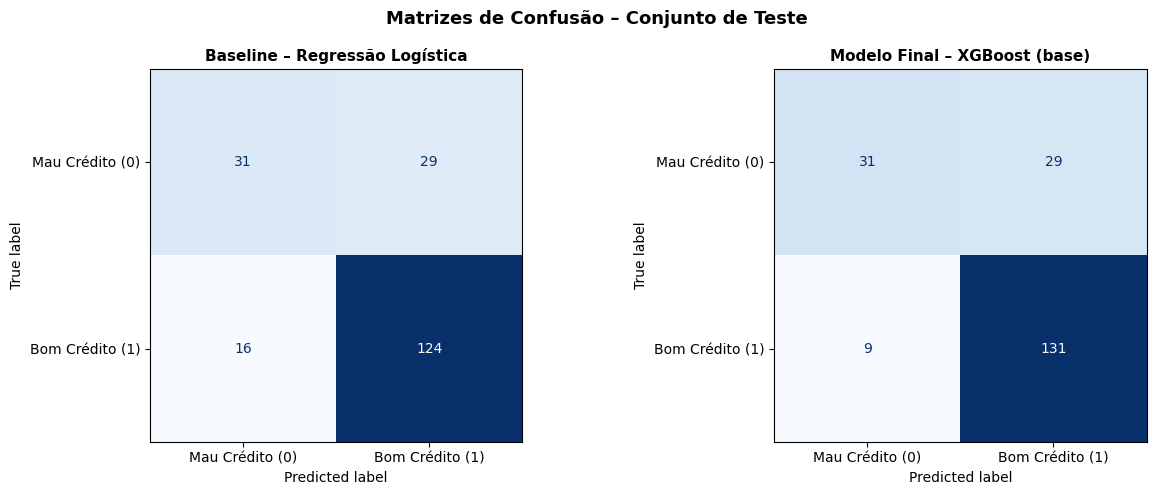

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (y_pred, titulo) in zip(axes, [
    (y_pred_baseline,   'Baseline – Regressão Logística'),
    (y_pred_final_sel,  f'Modelo Final – {nome_final}')
]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Mau Crédito (0)', 'Bom Crédito (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(titulo, fontsize=11, fontweight='bold')

plt.suptitle('Matrizes de Confusão – Conjunto de Teste', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
# Análise detalhada de erros
cm_final_sel = confusion_matrix(y_test, y_pred_final_sel)
tn, fp, fn, tp = cm_final_sel.ravel()

print('=== ANÁLISE DE ERROS DO MODELO FINAL ===')
print(f'Verdadeiros Negativos  (TN): {tn}  -> Mau crédito corretamente identificado')
print(f'Falsos Positivos       (FP): {fp}  -> Mau crédito aprovado incorretamente')
print(f'Falsos Negativos       (FN): {fn}  -> Bom crédito recusado incorretamente')
print(f'Verdadeiros Positivos  (TP): {tp}  -> Bom crédito corretamente aprovado')
print(f'\nTaxa de Falsos Positivos: {fp/(fp+tn)*100:.1f}% (risco financeiro para o banco)')
print(f'Taxa de Falsos Negativos: {fn/(fn+tp)*100:.1f}% (oportunidade de negócio perdida)')

=== ANÁLISE DE ERROS DO MODELO FINAL ===
Verdadeiros Negativos  (TN): 31  -> Mau crédito corretamente identificado
Falsos Positivos       (FP): 29  -> Mau crédito aprovado incorretamente
Falsos Negativos       (FN): 9  -> Bom crédito recusado incorretamente
Verdadeiros Positivos  (TP): 131  -> Bom crédito corretamente aprovado

Taxa de Falsos Positivos: 48.3% (risco financeiro para o banco)
Taxa de Falsos Negativos: 6.4% (oportunidade de negócio perdida)


### Curva ROC 

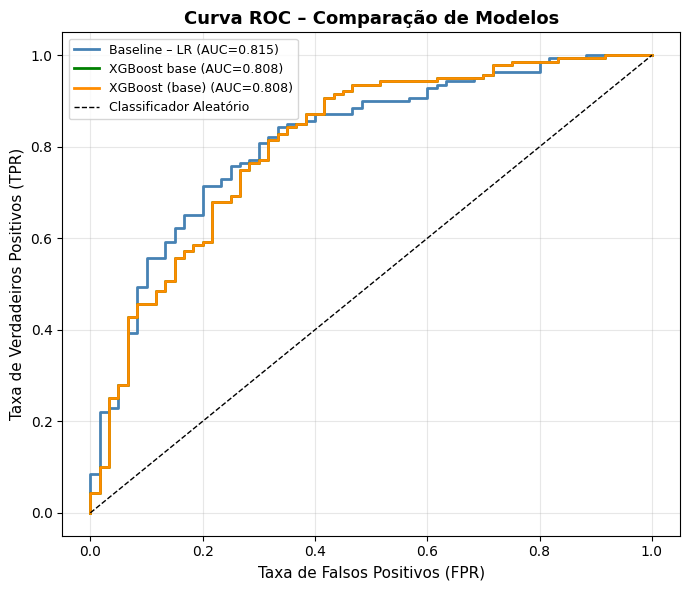

In [29]:
fig, ax = plt.subplots(figsize=(7, 6))

for y_prob, nome, cor in [
    (y_prob_baseline,    f'Baseline – LR (AUC={auc_baseline:.3f})', 'steelblue'),
    (y_prob_xgb,         f'XGBoost base (AUC={auc_xgb:.3f})', 'green'),
    (y_prob_final_sel,   f'{nome_final} (AUC={auc_final_sel:.3f})', 'darkorange'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, lw=2, label=nome, color=cor)

ax.plot([0,1],[0,1], 'k--', lw=1, label='Classificador Aleatório')
ax.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=11)
ax.set_title('Curva ROC – Comparação de Modelos', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Importância dos Atributos

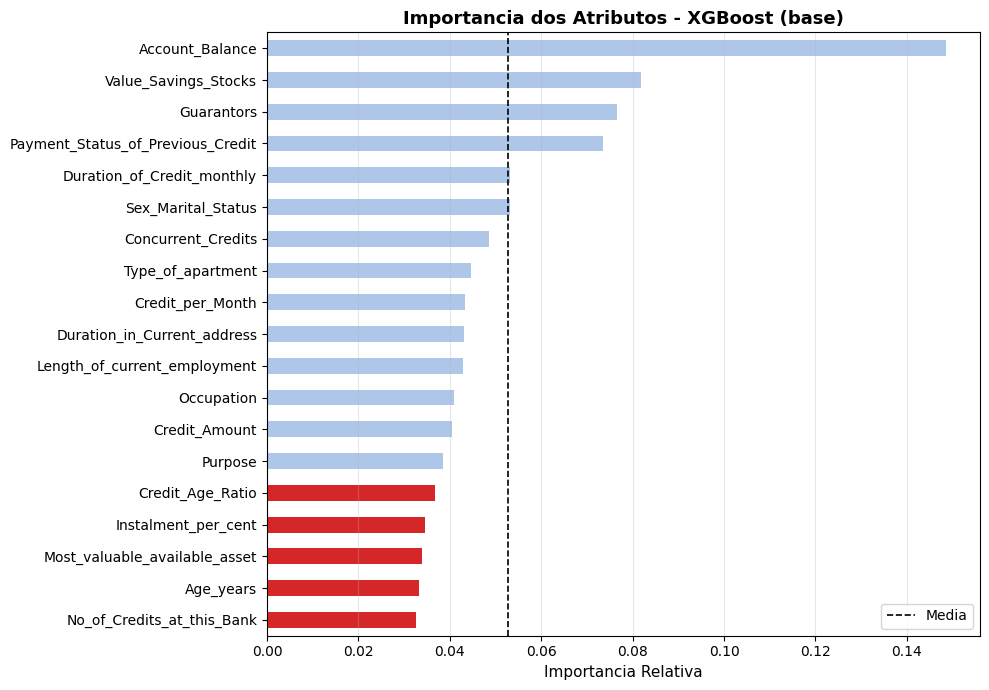


Top 5 variaveis mais importantes:
  1. Account_Balance: 0.1486
  2. Value_Savings_Stocks: 0.0817
  3. Guarantors: 0.0765
  4. Payment_Status_of_Previous_Credit: 0.0735
  5. Duration_of_Credit_monthly: 0.0532


In [30]:
importancias = pd.Series(
    xgb_smote.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
cores = ['#d62728' if i < 5 else '#aec7e8' for i in range(len(importancias))]
importancias.plot(kind='barh', ax=ax, color=cores[::-1])
ax.invert_yaxis()
ax.set_title(f'Importancia dos Atributos - {nome_final}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia Relativa', fontsize=11)
ax.axvline(importancias.mean(), color='black', linestyle='--', lw=1.2, label='Media')
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nTop 5 variaveis mais importantes:')
for i, (var, imp) in enumerate(importancias.head(5).items(), 1):
    print(f'  {i}. {var}: {imp:.4f}')

# Conclusão

(Ana Silva)

In [31]:
print('=' * 60)
print('       RESUMO FINAL – MILESTONE 3')
print('=' * 60)
print(f'  Modelo Selecionado:  {nome_final}')
print()
print(f'  F1-Score  (Teste):   {f1_final_sel:.4f}   (meta: ≥ 0.80)')
print(f'  AUC-ROC   (Teste):   {auc_final_sel:.4f}   (meta: ≥ 0.80)')
print(f'  Recall Mau (Teste):  {recall_final_sel:.4f}   (meta: ≥ 0.70)')
print()
print(f'  Meta F1-Score atingida:       {"✔ SIM" if f1_final_sel >= 0.80 else "✘ NÃO"}')
print(f'  Meta AUC-ROC  atingida:       {"✔ SIM" if auc_final_sel >= 0.80 else "✘ NÃO"}')
print(f'  Meta Recall (Risco) atingida: {"✔ SIM" if recall_final_sel >= 0.70 else "✘ NÃO"}')
print('=' * 60)

       RESUMO FINAL – MILESTONE 3
  Modelo Selecionado:  XGBoost (base)

  F1-Score  (Teste):   0.8733   (meta: ≥ 0.80)
  AUC-ROC   (Teste):   0.8082   (meta: ≥ 0.80)
  Recall Mau (Teste):  0.5167   (meta: ≥ 0.70)

  Meta F1-Score atingida:       ✔ SIM
  Meta AUC-ROC  atingida:       ✔ SIM
  Meta Recall (Risco) atingida: ✘ NÃO
